In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv('/content/retail_sales.csv')

In [5]:
df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,26-11-2013,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,26-11-2015,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,23-03-2014,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,23-03-2016,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,15-05-2014,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [6]:
df.shape

(113036, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost              113036 non-null  int

In [8]:
df.isnull().sum()

,0
Date,0
Day,0
Month,0
Year,0
Customer_Age,0
Age_Group,0
Customer_Gender,0
Country,0
State,0
Product_Category,0


In [9]:
df.dtypes

,0
Date,object
Day,int64
Month,object
Year,int64
Customer_Age,int64
Age_Group,object
Customer_Gender,object
Country,object
State,object
Product_Category,object


In [10]:
df.columns

Index(['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group',
       'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price',
       'Profit', 'Cost', 'Revenue'],
      dtype='object')

In [11]:
df.duplicated().sum()

np.int64(1000)

## Initial Dataset Observations

The dataset contains 113,036 records and 18 columns. It contains
information about customer demographics, products, sales quantities,
cost, revenue, and profit.

The dataset does not contain missing values. The Date column needs
to be converted from object format to datetime format before
performing time-series analysis.

In [12]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [13]:
df['Date'].dtype

dtype('<M8[ns]')

In [14]:
df[['Date', 'Month', 'Year']].head()

,Date,Month,Year
0,2013-11-26,November,2013
1,2015-11-26,November,2015
2,2014-03-23,March,2014
3,2016-03-23,March,2016
4,2014-05-15,May,2014


In [15]:
numerical_columns = df.select_dtypes(include='number').columns

numerical_columns

Index(['Day', 'Year', 'Customer_Age', 'Order_Quantity', 'Unit_Cost',
       'Unit_Price', 'Profit', 'Cost', 'Revenue'],
      dtype='object')

In [16]:
mean_values = df[numerical_columns].mean()

mean_values

,0
Day,15.665753
Year,2014.401739
Customer_Age,35.919212
Order_Quantity,11.901660
Unit_Cost,267.296366
Unit_Price,452.938427
Profit,285.051665
Cost,469.318695
Revenue,754.370360


In [17]:
median_values = df[numerical_columns].median()

median_values

,0
Day,16.0
Year,2014.0
Customer_Age,35.0
Order_Quantity,10.0
Unit_Cost,9.0
Unit_Price,24.0
Profit,101.0
Cost,108.0
Revenue,223.0


In [18]:
mode_values = df[numerical_columns].mode().iloc[0]

mode_values

,0
Day,24.0
Year,2014.0
Customer_Age,31.0
Order_Quantity,1.0
Unit_Cost,2.0
Unit_Price,5.0
Profit,3.0
Cost,1252.0
Revenue,35.0


In [19]:
std_values = df[numerical_columns].std()

std_values

,0
Day,8.781567
Year,1.272510
Customer_Age,11.021936
Order_Quantity,9.561857
Unit_Cost,549.835483
Unit_Price,922.071219
Profit,453.887443
Cost,884.866118
Revenue,1309.094674


In [20]:
descriptive_stats = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Standard Deviation': df[numerical_columns].std()
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
Day,15.665753,16.0,24.0,8.781567
Year,2014.401739,2014.0,2014.0,1.272510
Customer_Age,35.919212,35.0,31.0,11.021936
Order_Quantity,11.901660,10.0,1.0,9.561857
Unit_Cost,267.296366,9.0,2.0,549.835483
Unit_Price,452.938427,24.0,5.0,922.071219
Profit,285.051665,101.0,3.0,453.887443
Cost,469.318695,108.0,1252.0,884.866118
Revenue,754.370360,223.0,35.0,1309.094674


## Descriptive Statistics — Observations

The descriptive statistics provide an overview of the numerical variables in the retail sales dataset.

The mean and median values help understand the central tendency of the data, while the standard deviation indicates the variability of each numerical variable.

Revenue, Cost, and Profit show considerable variation across transactions, indicating differences in transaction size and product performance.

In [21]:
df['Date'].dtype

dtype('<M8[ns]')

In [22]:
monthly_sales = df.resample('M', on='Date')['Revenue'].sum()

monthly_sales.head()

/tmp/ipykernel_1992/1867611396.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Date')['Revenue'].sum()


,Revenue
Date,
2011-01-31,675193
2011-02-28,637598
2011-03-31,708517
2011-04-30,698782
2011-05-31,734537


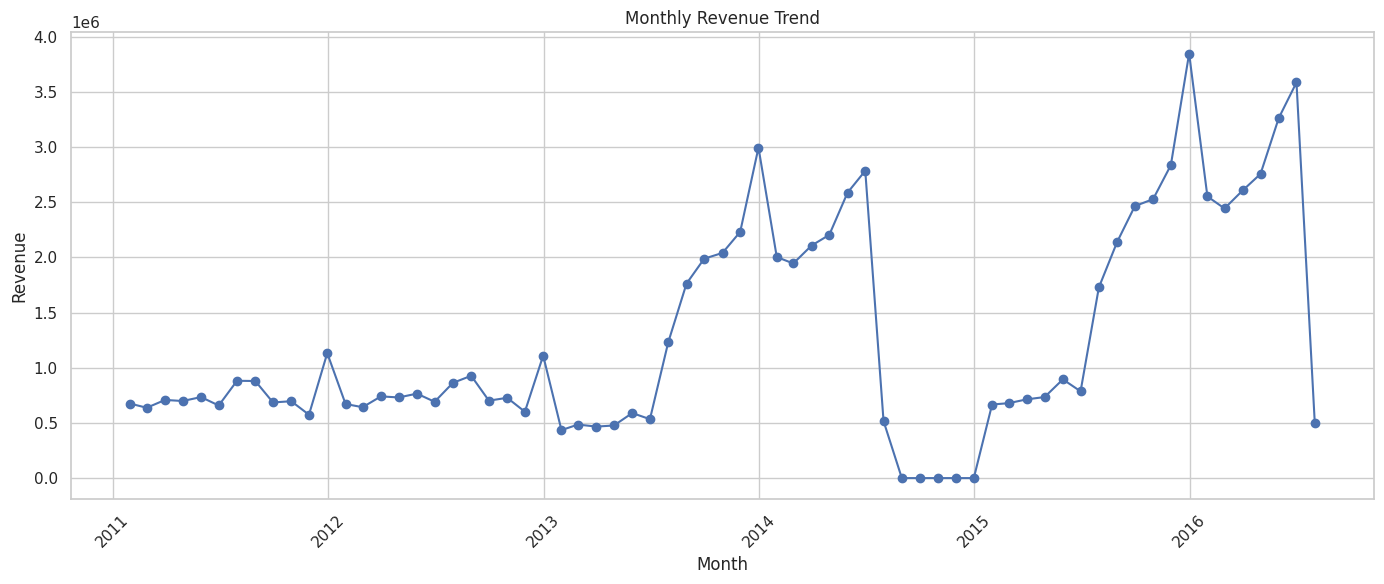

In [23]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

The monthly revenue trend shows how sales performance changes over time. Peaks in the graph indicate months with higher revenue, while lower points represent periods of relatively weaker sales.

The highest-revenue months can be further investigated to understand whether seasonal demand, product performance, or customer behaviour contributed to the increase.

In [24]:
quarterly_sales = df.resample('Q', on='Date')['Revenue'].sum()

quarterly_sales

/tmp/ipykernel_1992/3722618412.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_sales = df.resample('Q', on='Date')['Revenue'].sum()


,Revenue
Date,
2011-03-31,2021308
2011-06-30,2091457
2011-09-30,2448010
2011-12-31,2404113
2012-03-31,2055176
2012-06-30,2188536
2012-09-30,2492751
2012-12-31,2439520
2013-03-31,1387408


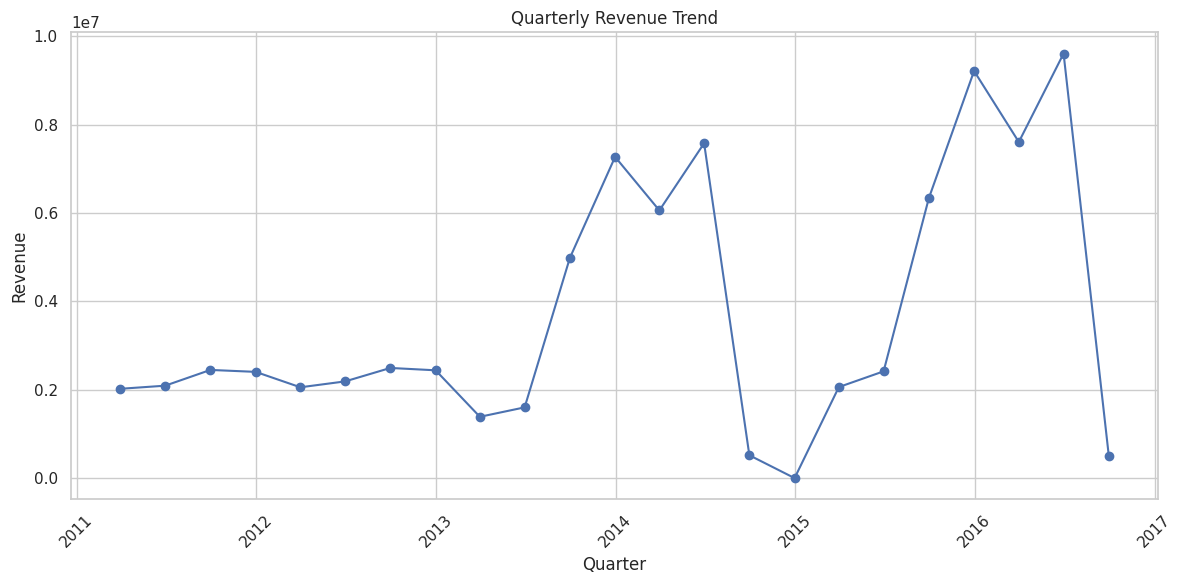

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker='o'
)

plt.title('Quarterly Revenue Trend')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

Quarterly analysis provides a broader view of sales performance than monthly analysis. It helps identify periods of sustained growth or decline and can be useful for business planning and inventory decisions.

In [28]:
df['Age_Group'].value_counts()

,count
Age_Group,
Adults (35-64),55824
Young Adults (25-34),38654
Youth (<25),17828
Seniors (64+),730


In [29]:
age_order = [
    'Youth (<25)',
    'Young Adults (25-34)',
    'Adults (35-64)',
    'Seniors (64+)'
]

df['Age_Group'].value_counts().reindex(age_order)

,count
Age_Group,
Youth (<25),17828
Young Adults (25-34),38654
Adults (35-64),55824
Seniors (64+),730


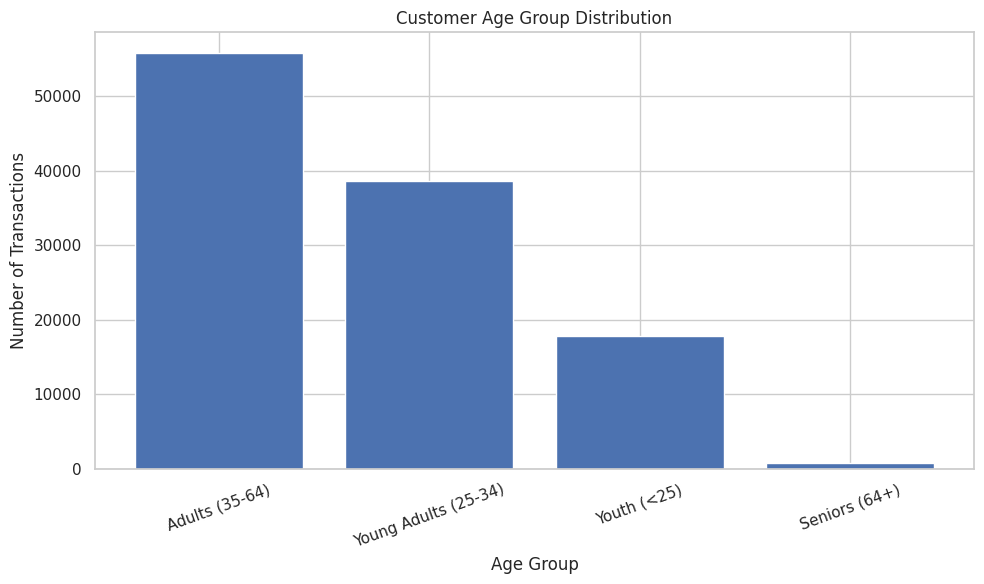

In [30]:
age_counts = df['Age_Group'].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(age_counts.index, age_counts.values)

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Observation

The age-group distribution shows how transactions are distributed across different customer segments. The largest age group represents the most frequently recorded customer segment, while smaller groups account for fewer transactions.

This information can help the business identify its primary customer segments and design targeted marketing strategies.

In [31]:
gender_counts = df['Customer_Gender'].value_counts()

gender_counts

,count
Customer_Gender,
M,58312
F,54724


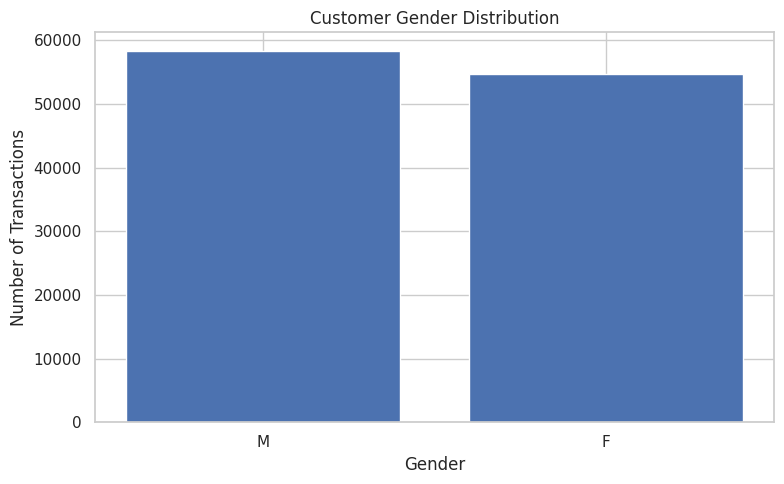

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(gender_counts.index, gender_counts.values)

plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

### Observation

The gender distribution shows the proportion of transactions made by different customer genders. The results can help identify whether the customer base is relatively balanced or concentrated toward a particular gender.

In [33]:
age_revenue = (
    df.groupby('Age_Group')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

age_revenue

,Revenue
Age_Group,
Adults (35-64),42584153
Young Adults (25-34),30655614
Youth (<25),11723199
Seniors (64+),308042


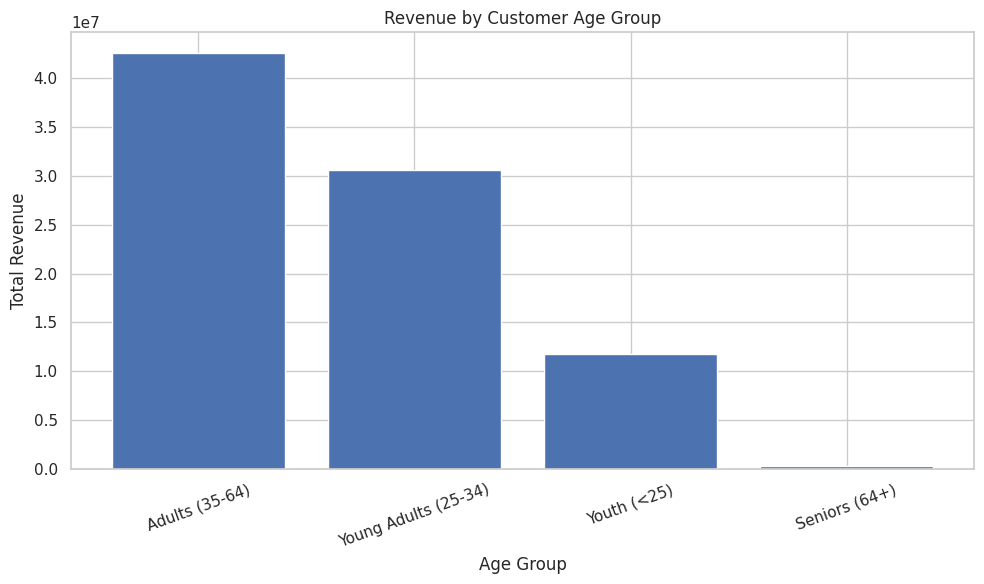

In [34]:
plt.figure(figsize=(10, 6))

plt.bar(age_revenue.index, age_revenue.values)

plt.title('Revenue by Customer Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [36]:
gender_revenue = (
    df.groupby('Customer_Gender')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

gender_revenue

,Revenue
Customer_Gender,
M,43335409
F,41935599


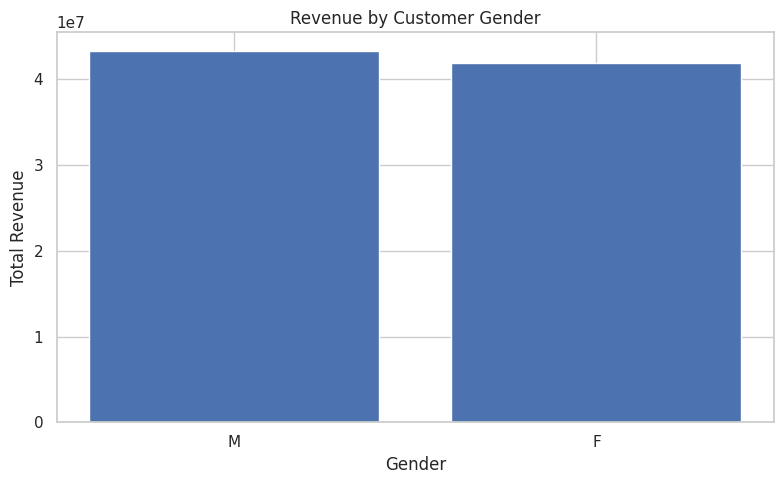

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(gender_revenue.index, gender_revenue.values)

plt.title('Revenue by Customer Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

### Observation

The revenue contribution from male and female customers is relatively balanced. Male customers generate slightly higher total revenue than female customers, but the difference is not very large. This suggests that the business should maintain marketing strategies for both customer groups rather than focusing heavily on only one gender.

In [38]:
top_products = (
    df.groupby('Product')['Order_Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Order_Quantity
Product,
Water Bottle - 30 oz.,164086
Patch Kit/8 Patches,157583
Mountain Tire Tube,102792
AWC Logo Cap,67316
"Sport-100 Helmet, Red",63663
Road Tire Tube,62296
Fender Set - Mountain,62118
"Sport-100 Helmet, Black",62105
Touring Tire Tube,56802


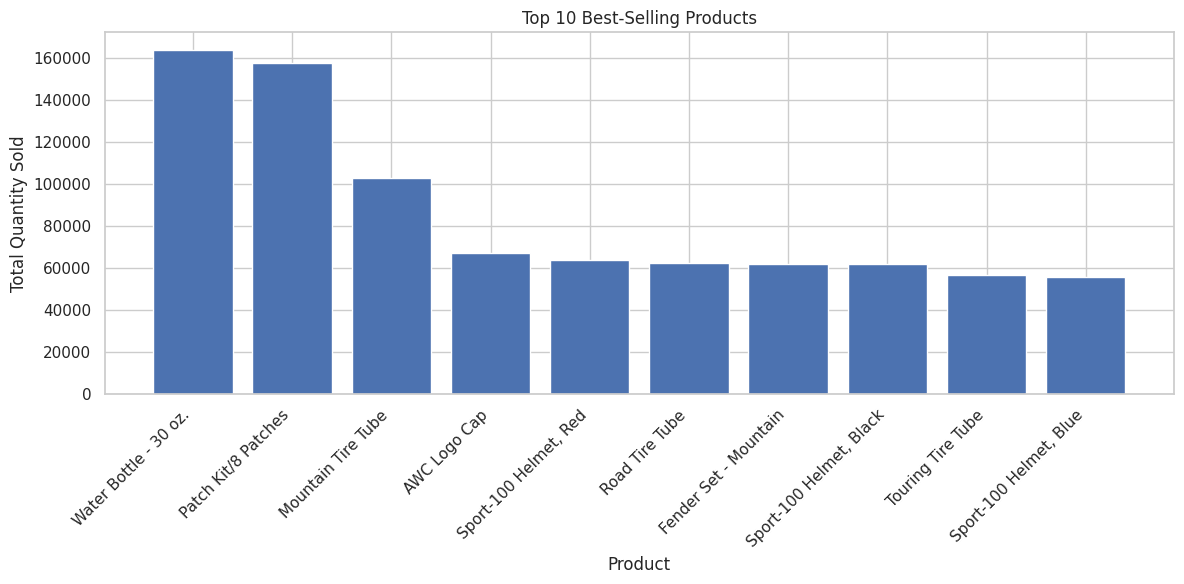

In [39]:
plt.figure(figsize=(12, 6))

plt.bar(top_products.index, top_products.values)

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Observation

The top-selling products are identified based on their total quantity sold. The products appearing at the top of the chart have the highest sales volume and may require greater inventory availability to meet customer demand.

In [40]:
category_revenue = (
    df.groupby('Product_Category')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

category_revenue

,Revenue
Product_Category,
Bikes,61782134
Accessories,15117992
Clothing,8370882


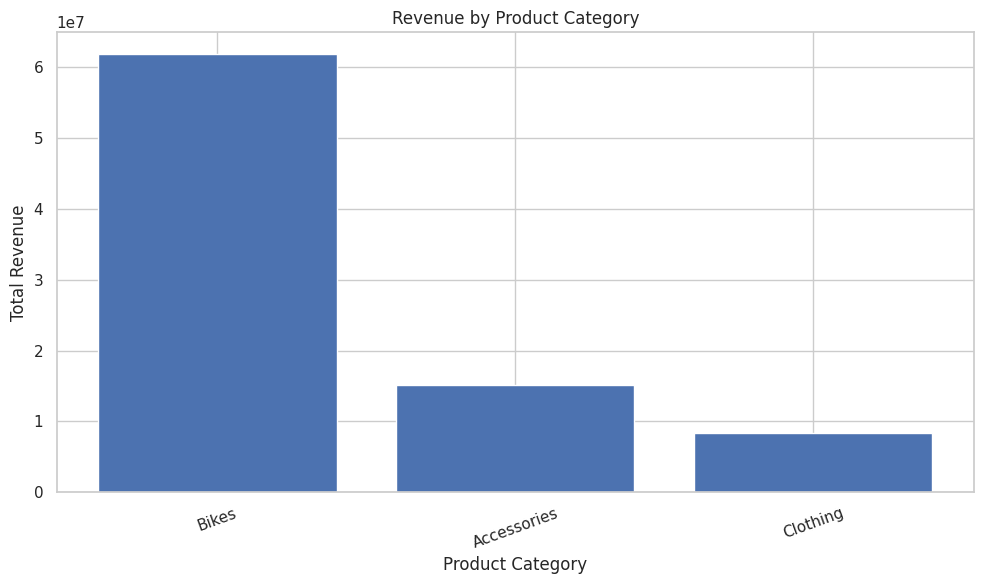

In [41]:
plt.figure(figsize=(10, 6))

plt.bar(category_revenue.index, category_revenue.values)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Observation

The revenue distribution varies across product categories. The category generating the highest revenue represents an important contributor to overall business performance, while lower-revenue categories may require further investigation to understand their weaker performance.

In [42]:
numerical_data = df.select_dtypes(include='number')

numerical_data.columns

Index(['Day', 'Year', 'Customer_Age', 'Order_Quantity', 'Unit_Cost',
       'Unit_Price', 'Profit', 'Cost', 'Revenue'],
      dtype='object')

In [43]:
correlation_matrix = numerical_data.corr()

correlation_matrix

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
Day,1.000000,-0.007635,-0.014296,-0.002412,0.003133,0.003207,0.004623,0.003329,0.003853
Year,-0.007635,1.000000,0.040994,0.123169,-0.217575,-0.213673,-0.181525,-0.215604,-0.208673
Customer_Age,-0.014296,0.040994,1.000000,0.026887,-0.021374,-0.020262,0.004319,-0.016013,-0.009326
Order_Quantity,-0.002412,0.123169,0.026887,1.000000,-0.515835,-0.515925,-0.238863,-0.340382,-0.312895
Unit_Cost,0.003133,-0.217575,-0.021374,-0.515835,1.000000,0.997894,0.741020,0.829869,0.817865
Unit_Price,0.003207,-0.213673,-0.020262,-0.515925,0.997894,1.000000,0.749870,0.826301,0.818522
Profit,0.004623,-0.181525,0.004319,-0.238863,0.741020,0.749870,1.000000,0.902233,0.956572
Cost,0.003329,-0.215604,-0.016013,-0.340382,0.829869,0.826301,0.902233,1.000000,0.988758
Revenue,0.003853,-0.208673,-0.009326,-0.312895,0.817865,0.818522,0.956572,0.988758,1.000000


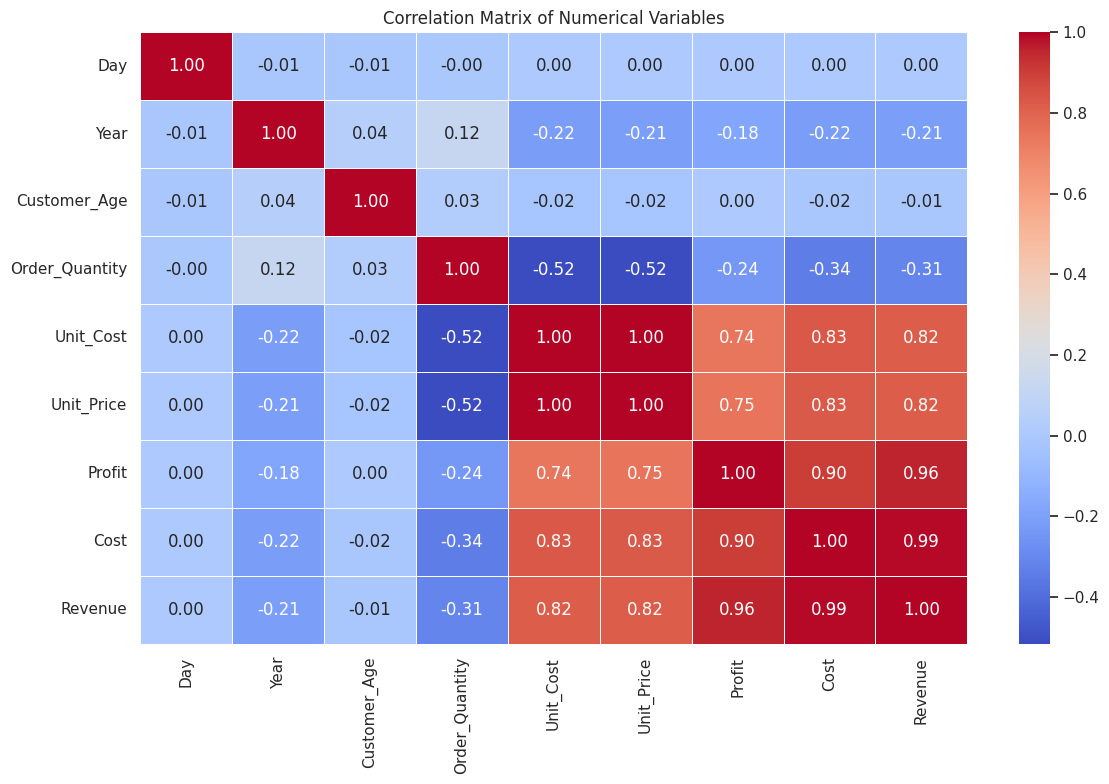

In [44]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()

plt.show()

## Correlation Heatmap — Observations

The correlation matrix shows several strong relationships among the financial variables.

Revenue has a very strong positive correlation with Cost (0.99) and Profit (0.96), indicating that higher-value transactions generally contribute to higher revenue and profit. Unit Cost and Unit Price also show strong positive correlations with Revenue (0.82).

Order Quantity has a moderate negative correlation with Unit Cost and Unit Price (approximately -0.52), suggesting that transactions with larger quantities tend to have lower unit prices and costs.

Customer Age has almost no correlation with Revenue or Profit, indicating that age alone does not have a strong linear relationship with financial performance.

In [45]:
category_performance = df.groupby('Product_Category').agg({
    'Revenue': 'sum',
    'Profit': 'sum'
})

category_performance

,Revenue,Profit
Product_Category,,
Accessories,15117992,8862377
Bikes,61782134,20519276
Clothing,8370882,2839447


In [46]:
category_performance['Profit_Margin'] = (
    category_performance['Profit'] /
    category_performance['Revenue']
) * 100

category_performance

,Revenue,Profit,Profit_Margin
Product_Category,,,
Accessories,15117992,8862377,58.621390
Bikes,61782134,20519276,33.212313
Clothing,8370882,2839447,33.920524


In [47]:
category_performance = category_performance.sort_values(
    'Profit_Margin',
    ascending=False
)

category_performance

,Revenue,Profit,Profit_Margin
Product_Category,,,
Accessories,15117992,8862377,58.621390
Clothing,8370882,2839447,33.920524
Bikes,61782134,20519276,33.212313


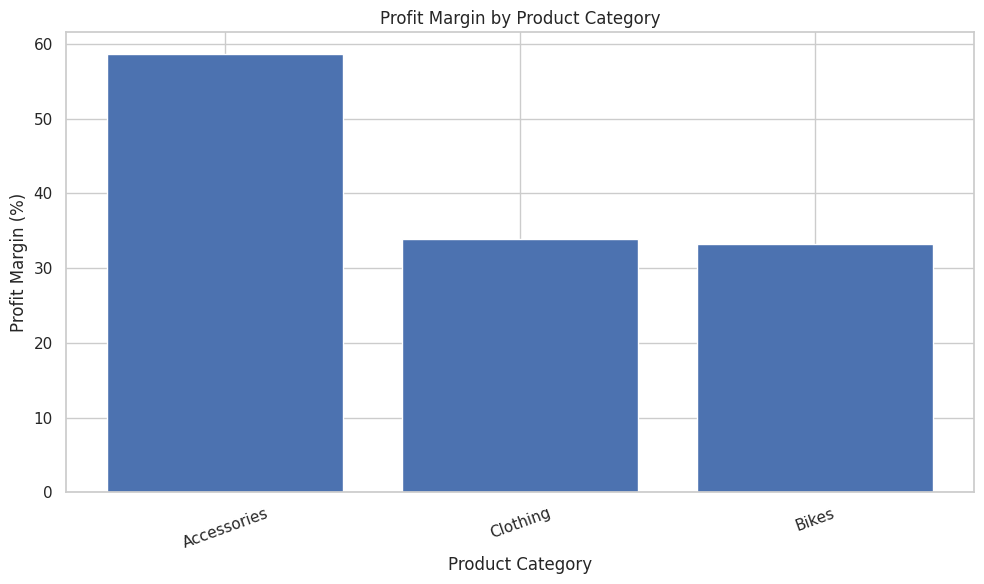

In [48]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_performance.index,
    category_performance['Profit_Margin']
)

plt.title('Profit Margin by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Profit Margin by Product Category — Observation

Accessories have the highest profit margin at approximately 58.5%, which is significantly higher than Clothing at approximately 33.8% and Bikes at approximately 33.0%.

This indicates that Accessories are considerably more profitable relative to their revenue. Therefore, the category with the highest revenue is not necessarily the category with the highest profit efficiency.

The business should consider the strong profitability of Accessories when planning product promotions, inventory, and future sales strategies.

# Business Recommendations

### 1. Increase focus on high-margin Accessories

Accessories generate the highest profit margin, at approximately 58.5%. The business should maintain adequate inventory for Accessories and consider targeted promotions or cross-selling strategies to increase their contribution to overall profit.

### 2. Plan inventory according to sales trends

The time-series analysis shows stronger revenue performance during 2015 and 2016. The business should use historical sales trends to forecast demand and prepare inventory before periods of increased sales.

### 3. Maintain marketing efforts across both genders

Revenue from male and female customers is relatively balanced, with male customers contributing slightly higher revenue. Therefore, marketing campaigns should continue targeting both customer groups rather than focusing exclusively on one gender.

### 4. Focus on profitable products rather than revenue alone

The analysis shows that high revenue does not necessarily mean the highest profit efficiency. The business should evaluate both revenue and profit margin when deciding which products and categories to promote, stock, and expand.

# Conclusion

The exploratory data analysis provided insights into sales trends, customer behaviour, product performance, and profitability within the retail dataset.

The time-series analysis showed an overall improvement in revenue during the later years of the dataset, particularly during 2015 and 2016. Customer demographic analysis showed a relatively balanced revenue contribution between male and female customers.

Product analysis identified the best-selling products and the revenue contribution of different product categories. The correlation analysis revealed strong relationships among important financial variables, particularly Revenue, Cost, and Profit.

The additional profit-margin analysis revealed that Accessories have the highest profit margin at approximately 58.5%, compared with approximately 33.8% for Clothing and 33.0% for Bikes.

Overall, the analysis suggests that the business should focus not only on sales volume and revenue but also on profitability, customer segments, and historical sales trends when making inventory, marketing, and product strategy decisions.